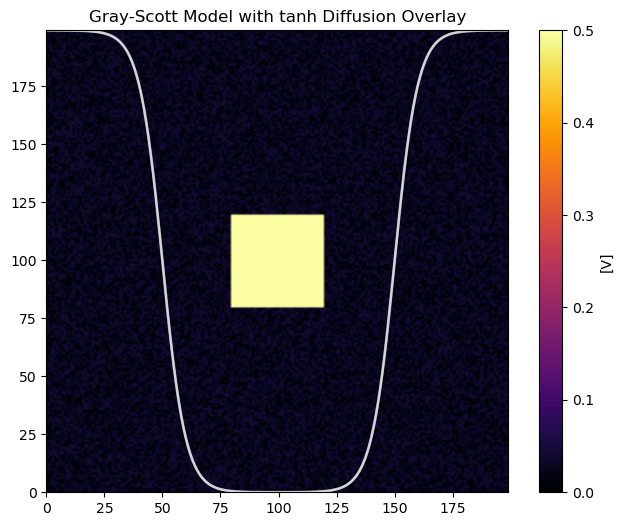

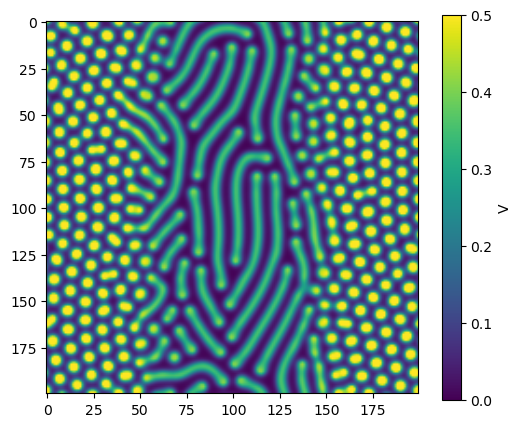

In [1]:
import numpy as np
import matplotlib.pyplot as plt


'''PARAMETERS'''

F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N
height = 3
dy = dx
n_steps =  400 #10000 #Using 300 for video. 
p1 = 50
p2 = 200-p1
s = 0.1 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2 # keep at 0.1 normally
x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)

scale = 0.16


input1 = s * (x - p1) #so, this creates a bunch of values between the two boundries and creates them into inputs for the tanh functions
input2 =  s * -1 * (x - p2)
tanfunc =   scale * ((height - 1)/2 * (2-np.tanh(input1) - np.tanh(input2)) +1) #now that we have a bunch of values between these two boundries, we can use the tanh function to create a bunch of diffusion constants between those two boundries
Du =  np.full((N,N), tanfunc) #Now a bunch of diffusion constants are created between those two boundries which all change. Each is slightly different, but the main change is at 25 and 75. So after those, the 
#diffusion constants are much lower. Currently, with sharpess = 0.1, and pi = 25 with p2 = 75, the diffusion constants are between 0 and 2. So we can define Dv later with the same process, maybe just saying that Dv = 2 * Du
Dv =  (scale/2) * np.ones_like(Du)  # Dv = 0.08 For now I have placed Dv = Du/2 because that is the ratio we have been using so far. I still don't know why works, but it does.

dt = ((dx)**2)/(4 * Du.max())-0.1 #This is the time step, which is based on the diffusion constant. This is a function for the time step. 

'''FUNCTIONS'''

def first_derivative(M, axis):
    firstD = (np.roll(M, 1, axis) - np.roll(M, -1, axis)) / (2 * dx)
    return firstD
        
def product_derivative(D, Concentration):
    dD_dx = first_derivative(D, 0)
    dU_dx = first_derivative(Concentration, 0)
    dD_dy = first_derivative(D, 1)
    dU_dy = first_derivative(Concentration, 1)
    return dD_dx * dU_dx + dD_dy * dU_dy

def laplacian(Z, dx):
    d2Z_dx2 = np.roll(Z, 1, 1) - 2 * Z + np.roll(Z, -1, 1) #FEB 16th - I am looking at this laplacian function. Should the axis for dx be 1?? and y should have axis 0. Is this why I am having errors?
    d2Z_dy2 = np.roll(Z, 1, 0) - 2 * Z + np.roll(Z, -1, 0) 

    derivative = (d2Z_dx2 + d2Z_dy2)/(dx * dx) 
    # should this not be (d2Z_dx2/dx * dx) + (d2Z_dy2/dy * dy)? I think we are saying that 
    #dy = dx. So it doesn't matter and we combine like terms. 
    return derivative


def solver(U, V, Du, Dv, F, k, dx, dt):
    Lu = laplacian(U, dx)
    Lv = laplacian(V, dx)

    uvv = U * V * V

    U += (Du * Lu + product_derivative(Du,U) - uvv + F * (1 - U)) * dt
    V += (Dv * Lv + product_derivative(Dv,V) + uvv - (F+k) * V) * dt
    #Here is forward euler's method for the next time step. 
    return U, V

''''INTIAL CONDITIONS'''

U = np.ones((N,N))
V = np.zeros((N,N))


r = 20
U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
U += 0.05 * np.random.rand(N,N)
V += 0.05 * np.random.rand(N,N)

'''GRAPHING AND MAKING THINGS LOOK PRETTY'''
fig, ax = plt.subplots(figsize=(8,6)) #regular sizing in a cube

im = ax.imshow(V, cmap='inferno', interpolation='bilinear', vmin=0, vmax=0.5)
plt.axis('on')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('[V]')

tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

# x-coordinates: pixel indices (0 to N-1)
x_coords = np.arange(N)

# Overlay line: static sine curve
tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=1.5, alpha=0.6)

# Set axes to avoid autoscaling that might hide the line
ax.set_xlim(0, N-1)
ax.set_ylim(0, N-1)

ax.set_title('Gray-Scott Model with tanh Diffusion Overlay')

''' SOLVE FOR CONCENTRATIONS '''

total_V_concentration = np.zeros(n_steps)
total_time = np.zeros(n_steps)

for i in range(n_steps):
    for _ in range(100):
        U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    
    total_time[i] = i * dt 
    total_V_concentration[i] = np.sum(V)

''''PLOT FINAL TIMESTEP'''

plt.figure(figsize=(6,5))
tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

# x-coordinates: pixel indices (0 to N-1)
x_coords = np.arange(N)

# Overlay line: static sine curve
tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=2, alpha=0.6)


plt.imshow(V, cmap='viridis', interpolation='bilinear', vmin=0, vmax=0.5)
#plt.title('Du as a Function of space (Hyperbolic Tangent)')
plt.colorbar(label='V')
plt.show()






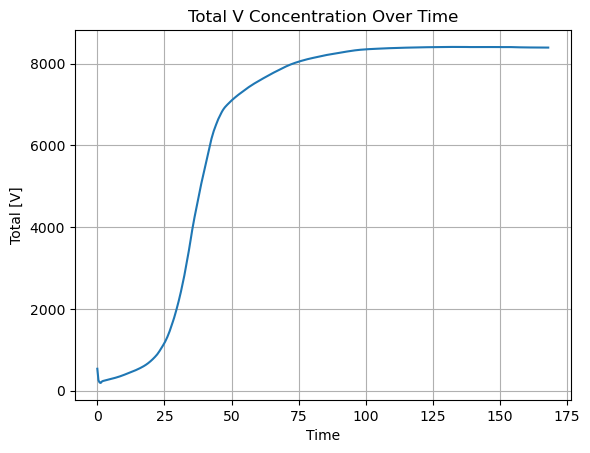

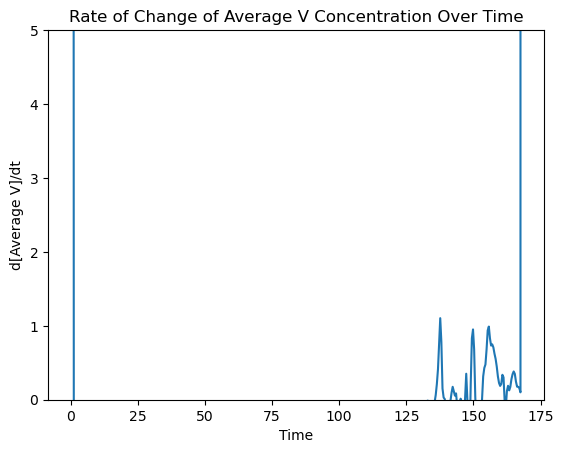

In [3]:
plt.figure()
plt.plot(total_time, total_V_concentration)
plt.title('Total V Concentration Over Time')
plt.xlabel('Time')
plt.ylabel('Total [V]')
plt.grid(True)
plt.show()

plt.figure()
plt.plot(total_time, first_derivative(total_V_concentration,0))
plt.title('Rate of Change of Average V Concentration Over Time')
plt.xlabel('Time')
plt.ylabel('d[Average V]/dt')
plt.ylim(0,5)
plt.show()

(200,) (200, 200)


[]

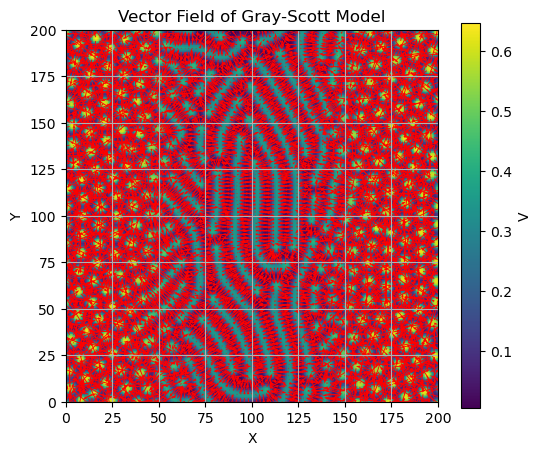

In [4]:
dVx = first_derivative(V, 1)
dVy = first_derivative(V, 0)


skip = 2 # keep as 4 regularly
print(x.shape, dVx.shape)

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.title('Gray Scott')
plt.colorbar(label='V')
plt.xlim(0,200)
plt.ylim(0,200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

plt.quiver(x[::skip], y[::skip], dVx[::skip,::skip], dVy[::skip, ::skip], color='red', scale=3)

plt.plot()

p1= 50


[]

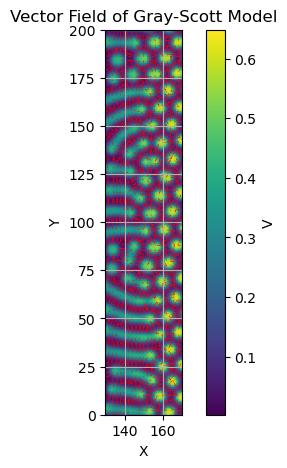

In [15]:
'''EDGE SECTION ONLY'''

mask_condition = 0
# 0 = edge section  

x3, y3 = np.meshgrid(np.arange(N), np.arange(N))
print( 'p1=', p1)
bound = 20

mask_edge1 = x3 < p2 - bound
mask_edge2 = x3 > p2 + bound

mask_edge = mask_edge1 | mask_edge2

final_mask_edge = mask_edge1 | mask_edge2

dVx2 =~final_mask_edge * dVx
dVy2= ~final_mask_edge * dVy

skip = 2
# Downsample both coordinate grids and vector components consistently
x_ds = x3[::skip, ::skip]
y_ds = y3[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(p2-bound, p2+bound)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1, width=0.005)

plt.plot()



[]

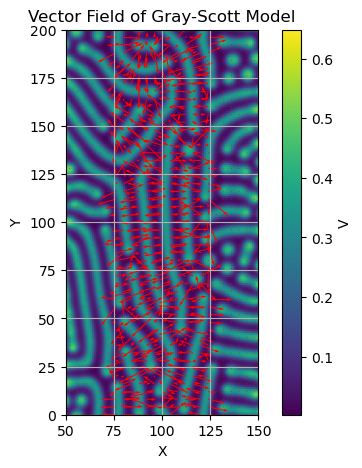

In [27]:
'''INNER SECTION CALCULATIONS + MASKING'''

mask_condition = 1

# 1 = inner section

x2, y2 = np.meshgrid(np.arange(N), np.arange(N))

mask1 = x2 < p1+25
mask2 = x2 > p2-25


final_mask = mask1 | mask2

dVx2 =~final_mask * dVx
dVy2= ~final_mask * dVy



skip = 4
# Downsample both coordinate grids and vector components consistently
x_ds = x2[::skip, ::skip]
y_ds = y2[::skip, ::skip]
dVx_ds = dVx2[::skip, ::skip]
dVy_ds = dVy2[::skip, ::skip]

plt.figure(figsize=(6,5))
plt.imshow(V, cmap='viridis')
plt.colorbar(label='V')
plt.xlim(p1,p2)
plt.ylim(0, 200)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Vector Field of Gray-Scott Model')
plt.grid()

# Overlay vector field
plt.quiver(x_ds, y_ds, dVx_ds, dVy_ds, color='red', scale=1, width=0.005)

plt.plot()

In [28]:
'''To calc cosine theta and frequency with MASKING''' 
'''LOOK HERE FOR FEB 7th, 2026'''

def dot_product(a, b):
    return a[0]*b[0] + a[1]*b[1]

a = [1,0]

dV = [dVx2,dVy2]
dV_new = np.stack((dVy, -1 * dVx), axis = 0)
resultant = dot_product(a, dV_new)


cos_theta = resultant / (np.sqrt(dVx**2 + dVy**2) * np.sqrt(a[0]**2 + a[1]**2)) 

'''I FIGURED OUT THE ERROR - it was that all of the masked values were 0 and they were all also being plotted'''
'''I should include something where it defines that if the values are masked then they should not be plotted. So what i will do is for theta in some range, plot those values'''
print('cos_theta:', cos_theta[100,100])


'''this is where we transform cosine theta to cosine 2 theta and then to theta, which is the angle between the vector and the x-axis. '''

cos_theta_squared = cos_theta**2

cos_2_theta = 2 * cos_theta_squared - 1

theta = 0.5 * np.arccos(cos_2_theta)

theta = theta * (180/np.pi) #convert to degrees

theta_region = theta[~final_mask]

#theta_region = theta[~final_mask_edge]

print('theta_region:', np.mean(theta_region))

cos_theta: -0.0631930841686944
theta_region: 63.42157051821771


theta [45.22340301 45.41831607 45.39741075 45.41787129 45.31592932 45.04609052
 44.99764962 44.90298951 44.93776846 45.23989889 45.4328251  45.14063053
 44.94349735 44.80193096 44.64299814 44.64395924 44.80183106 44.71244964
 44.74208385 44.57168948 44.33181719 44.14219491 44.10215351 44.07415461
 44.03038683 44.13263068 44.02288446 43.89206188 43.73688133 43.29499333
 43.03796603 43.06597993 43.19434483 43.28732317 43.30914368 43.27793887
 43.25863993 43.22947079 43.03313165 43.21296746 43.39591783 43.62194091
 43.83041192 43.64752011 43.55705796 43.62188019 43.81579311 44.16686905
 44.65908602 45.48383742 46.38247085 47.23507271 47.77054137 48.03060357
 48.4646753  49.03946711 49.65018812 50.4893938  51.43630581 52.10390348
 52.58537069 52.99694721 53.39949704 54.18910146 54.92433465 55.55185511
 56.25415934 56.87277367 57.52507151 57.84141937 58.01324448 58.17386886
 58.46297426 58.85040294 58.98826508 59.14405515 59.39842353 59.65614027
 59.88865151 59.98361014 59.97279973 59.96628

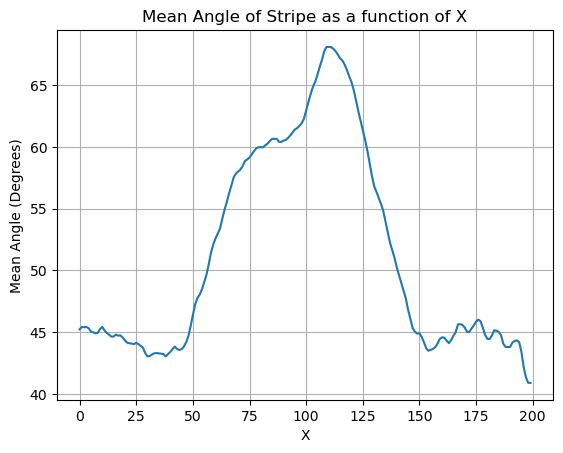

In [5]:
'''To calculate without a mask for the new plot'''

def dot_product(a, b):
    return a[0]*b[0] + a[1]*b[1]

def solve_for_theta(dVx, dVy):
    a = [1,0]

    dV = np.stack((dVx,dVy), axis = 0)

    dV_new = np.stack((dVy, -1 * dVx), axis = 0) #This takes dv and makes it perpendicluar to the orginal vector. 
    #Here we take Dv which is shooting in the x dire wrt to the stripe. Then we just orient the vector to dir of the stripe. 

    resultant = dot_product(a, dV_new)


    cos_theta = resultant / (np.sqrt(dVx**2 + dVy**2) * np.sqrt(a[0]**2 + a[1]**2)) 

    # theta = np.arctan(dVy/dVx)

    #theta = np.arccos(cos_theta) * (180/np.pi) #convert to degrees


    '''this is where we transform cosine theta to cosine 2 theta and then to theta, which is the angle between the vector and the x-axis. '''

    cos_theta_squared = cos_theta**2

    cos_2_theta = 2 * cos_theta_squared - 1

    theta = 0.5 * np.arccos(cos_2_theta)

    theta = theta * (180/np.pi) #convert to degrees
    mean_theta_column = np.mean(theta, axis = 0)
    return mean_theta_column




theta_to_plot = np.zeros_like(solve_for_theta(dVx, dVy))


for i in range(0, len(solve_for_theta(dVx, dVy)), 1):
    theta_to_plot[i] = np.mean(solve_for_theta(dVx, dVy)[i:i+20])




print('theta', theta_to_plot)






plt.figure()
plt.plot(x, theta_to_plot)
plt.xlabel('X')
plt.ylabel('Mean Angle (Degrees)')
plt.title('Mean Angle of Stripe as a function of X')
plt.grid()
plt.show()




 

In [84]:
print(dV.shape)

(2, 200, 200)


In [23]:
'''PLOTS FOR COS THETA. '''
#This is where we can see cos theta without the masking values interuptting. This shows us the thing we discussed about "one value -  0 or 1 and giving that meaning"
#below is the plotting for theta anyway which is more interesting I think


counts, bin_edges = np.histogram(cos_theta[~final_mask], bins=50)

bins = np.linspace(-1,1,41) #for degrees

hist, bin_edge = np.histogram(cos_theta[~final_mask], bins, density=True)

if mask_condition == 1:
    print('inner section')
    plt.title('Distribution of Cos Theta in "Inner Section" ')
else:
    print('edge section')
    plt.title('Distribution of Cos Theta in "Edge Section" ')

bin_label = (bins[1:] + bins[:-1])/2
plt.plot(bin_label, hist)


NameError: name 'final_mask' is not defined

Rank 1: Bin center = 87.2987, Frequency = 827
Rank 2: Bin center = 85.4987, Frequency = 744
Rank 3: Bin center = 83.6988, Frequency = 583
Rank 4: Bin center = 89.0986, Frequency = 562
Rank 5: Bin center = 80.0988, Frequency = 469
Rank 6: Bin center = 81.8988, Frequency = 451
Rank 7: Bin center = 76.4989, Frequency = 417
Rank 8: Bin center = 78.2989, Frequency = 414
Rank 9: Bin center = 74.6990, Frequency = 393
Rank 10: Bin center = 72.8990, Frequency = 354
inner section
Median: 72.64814418485724
Mean: 63.42157051821771


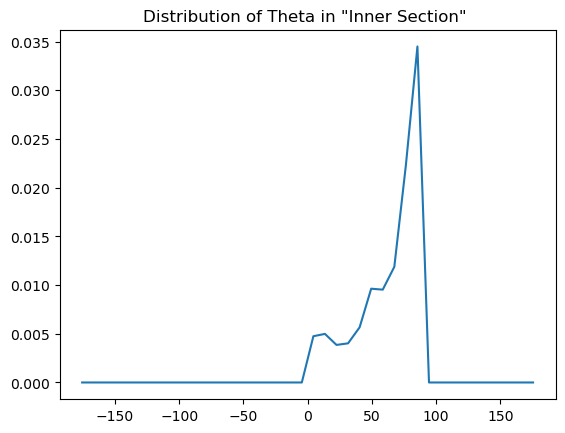

In [29]:
'''To plot theta and frequency'''

counts, bin_edges = np.histogram(theta_region, bins=50)

# Sort counts in descending order and get top 3 indices
top_indices = np.argsort(counts)[::-1][:10] #keep [:#] as 3 for top 3

# Get the bin centers and their counts
top_bins = [( (bin_edges[i] + bin_edges[i+1]) / 2, counts[i]) for i in top_indices]

# Print results
for rank, (center, freq) in enumerate(top_bins, start=1):
    print(f"Rank {rank}: Bin center = {center:.4f}, Frequency = {freq}")
    

bins = np.linspace(-180,180,41) #for degrees

hist, bin_edge = np.histogram(theta_region, bins, density=True)

if mask_condition == 1:
    print('inner section')
    plt.title('Distribution of Theta in "Inner Section" ')
else:
    print('edge section')
    plt.title('Distribution of Theta in "Edge Section" ')

bin_label = (bins[1:] + bins[:-1])/2
plt.plot(bin_label, hist)

print('Median:', np.median(theta_region))

print('Mean:', np.mean(theta_region))



In [6]:
'''Multiple simulations'''

from multiprocessing import Pool, cpu_count

def run_simulation(seed): 

    np.random.seed(seed)

    U = np.ones((N,N))
    V = np.zeros((N,N))
    r = 20
    U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
    V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
    U += 0.05 * np.random.rand(N,N)
    V += 0.05 * np.random.rand(N,N)


    for i in range(n_steps):
        for _ in range(100):
            U, V = solver(U, V, Du, Dv, F, k, dx, dt)

    dVx = first_derivative(V, 1)
    dVy = first_derivative(V, 0)

    return solve_for_theta(dVx, dVy)


if __name__=='__main__':
    num_simulations = 10
    seeds = np.arange(num_simulations)

    with Pool(cpu_count()) as pool:
        results = pool.map(run_simulation, seeds)

        results = np.array(results)

        mean_theta = np.mean(results, axis=0)

    for i, theta_result in enumerate(results):
        print(f"Simulation {i+1}: Mean Theta = {np.mean(theta_result):.4f} degrees")

plt.plot(x, mean_theta)
plt.xlabel('X')
plt.ylabel('Mean Theta (degrees)')
plt.title('Mean Theta vs X')
plt.show()


Process SpawnPoolWorker-19:
Process SpawnPoolWorker-21:
Process SpawnPoolWorker-20:
Process SpawnPoolWorker-22:
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
  File "/Users/swetansinha/miniconda/envs/diffusion/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
  File "/Users/swetansinha/miniconda/envs/diffusion/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/swetansinha/miniconda/envs/diffusion/lib/python3.13/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/Users/swetansinha/miniconda/envs/diffusion/lib/python3.13/multiprocessing/queues.py", line 387, in get
    return _ForkingPickler.loads(res)
           ~~~~~~~~~~~~~~~~~~~~~^^^^^
AttributeError: Can't get attribute 'run_simulation' on <module '__main__' 

KeyboardInterrupt: 